In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

from libpysal import weights

In [ ]:
from pathlib import Path

DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)


### Read in source files 

In [2]:
# study area gdfs 
new_ea = gpd.read_file(DATA_DIR / 'miscellaneous/new_ea.json')
new_data_study_area = gpd.read_file(DATA_DIR / 'miscellaneous/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file(DATA_DIR / 'miscellaneous/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file(DATA_DIR / 'miscellaneous/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [3]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [4]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file(DATA_DIR / 'miscellaneous/district_2021_census.geojson')

In [5]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

### Revised EA shapefile  

In [6]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

## Outages 

In [7]:
## 2022 
geo_pqr_22 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_22_NEW.csv')
geo_pqr_22 = geo_pqr_22.drop(columns = ['Unnamed: 0'])
geo_pqr_22 = geo_pqr_22[['time', 'site_id', 'outage_events', 'outage_mins']]

## 2023 
geo_pqr_23 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_23_NEW.csv')
geo_pqr_23 = geo_pqr_23.drop(columns = ['Unnamed: 0'])
geo_pqr_23 = geo_pqr_23[['time', 'site_id', 'outage_events', 'outage_mins']]

In [8]:
## concatenate 
geo_pqr_all = pd.concat([geo_pqr_22, geo_pqr_23], ignore_index=True)
geo_pqr_all['time'] = pd.to_datetime(geo_pqr_all['time'])
geo_pqr_all = geo_pqr_all[~(geo_pqr_all['site_id'] == 0)]

### 1+ hour outages 

In [9]:
dur = 60

# filter out outages with duration >= dur 
geo_pqr_all['outage_mins_dur'] = (
    np.floor(geo_pqr_all['outage_mins'] / dur)
).where(geo_pqr_all['outage_mins'] >= dur, 0)


# Set outage_events to 0 where outage_hours_dur is 0
geo_pqr_all['outage_events_adj'] = geo_pqr_all['outage_events'].where(
    geo_pqr_all['outage_mins_dur'] > 0, 0
)

geo_dur_grouped = geo_pqr_all.groupby('site_id')[['outage_events_adj', 'outage_mins_dur']].sum().reset_index()

## 60min / 1hr 
geo_dur_grouped = geo_dur_grouped.rename(columns = {'outage_events_adj':'60min_outage_events'})

## remove site '0'
geo_dur_grouped = geo_dur_grouped[~(geo_dur_grouped['site_id'] == 0)]

##
geo_1hr_grouped = geo_dur_grouped.copy()

### Find average metrics for EAs with multiple sites 

In [10]:
def compute_avg_values(site_list, df, event_col):
    geo_lookup = df.set_index('site_id')
    
    # Only use site_ids that are in geo_lookup
    valid_sites = [site for site in site_list if site in geo_lookup.index]
    
    if not valid_sites:
        return pd.Series({
            event_col: np.nan,
            # duration_col: np.nan
        })

    matching = geo_lookup.loc[valid_sites]
    avg_events = matching[event_col].mean()
    # avg_duration = matching[duration_col].mean()
    
    return pd.Series({
        event_col: avg_events,
        # duration_col: avg_duration
    })

In [11]:
##### Outage Metrics ##### 

# copy of df 
grouped_sites_df_rez = grouped_sites_df.copy()


### 1+ hour 
averages_df = grouped_sites_df['site_id'].apply(
    lambda site_list: compute_avg_values(
        site_list,
        df = geo_1hr_grouped,
        event_col = '60min_outage_events',
    )
)
grouped_sites_df_rez = grouped_sites_df_rez.join(averages_df)

In [12]:
## drop null values 
grouped_sites_df_rez = grouped_sites_df_rez.dropna()

### CESI and Average Grid Metrics per EA 

In [13]:
## set ea_code as index, select the CESI column and tack on Average Grid Metrics per EA data 
if new_data_study_area.index.name != 'ea_code9ch':
    new_data_study_area = new_data_study_area.set_index('ea_code9ch')

new_data_study_area_copy = new_data_study_area.copy()[['climate_vul_add']]
new_data_study_area_copy = new_data_study_area_copy.join(grouped_sites_df_rez).dropna()

### Using K_Means to classify *CESI* into clusters (Low, Mid, High) 

In [14]:
cesi_df = new_data_study_area_copy.copy()[['climate_vul_add']]

cesi_values = cesi_df[['climate_vul_add']].values

# Run KMeans

# random state (42) ensures you get the same results each time you run the code 
# n_init -> how many times to run the algorithm. using default state 
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
cesi_df['cesi_cluster'] = kmeans.fit_predict(cesi_values)

# Map clusters to 'Low', 'Mid', 'High' based on cluster centers
# Sort cluster labels by increasing vulnerability
cluster_order = kmeans.cluster_centers_.flatten().argsort()
label_map = {cluster: label for cluster, label in zip(cluster_order, ['Low', 'High'])}
cesi_df['cesi_level'] = cesi_df['cesi_cluster'].map(label_map)

cesi_df = cesi_df.drop(columns=['cesi_cluster', 'climate_vul_add'])

In [15]:
### Assign output of K_Means Clustering back to df 
new_data_study_area_copy = new_data_study_area_copy.join(cesi_df)

### Using K_Means to classify *Grid Metrics* into clusters (Low, Mid, High) 

In [16]:
def add_outage_level_kmeans(
    df, 
    col='60min_outage_events', 
    n_clusters=3, 
    random_state=42,
    exclude_outlier_percentile=0.95  
):
    outage_df = df[[col]].copy()

    # Exclude top X percentile for clustering (outliers have unusually high values)
    if exclude_outlier_percentile is not None:
        threshold = outage_df[col].quantile(exclude_outlier_percentile)
        inlier_mask = outage_df[col] <= threshold
    else:
        inlier_mask = np.ones(len(outage_df), dtype=bool)

    # Fit KMeans only on inlier data
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    kmeans.fit(outage_df.loc[inlier_mask, [col]])

    # Predict cluster for all data (including outliers)
    outage_df['outage_cluster'] = kmeans.predict(outage_df[[col]])

    # Sort cluster labels by cluster center
    cluster_order = kmeans.cluster_centers_.flatten().argsort()
    label_map = {cluster: label for cluster, label in zip(cluster_order, ['Low', 'Medium', 'High'])}
    outage_df[f'{col}_level'] = outage_df['outage_cluster'].map(label_map)

    # Keep only the labeled column
    outage_level_df = outage_df[[f'{col}_level']]
    
    # Join back to the original DataFrame
    df_out = df.copy()
    df_out = df_out.join(outage_level_df)
    
    return df_out

### Run K-Means clustering on df  

In [17]:
### Outages 

updated_study_area_df = add_outage_level_kmeans(new_data_study_area_copy, col='60min_outage_events', exclude_outlier_percentile=0.95)

### Generate Bins for Grid Metrics 

In [18]:
def get_outage_bin_edges(df, value_col, level_col):

    levels = df.groupby(level_col)[value_col].agg(['min', 'max'])
    
    # Ensure consistent order
    levels = levels.loc[['Low', 'Medium', 'High']]

    # Create bin edges: min of Low, min of Medium, min of High, and inf
    bin_edges = [
        levels.loc['Low', 'min'],
        levels.loc['Medium', 'min'],
        levels.loc['High', 'min'],
        np.inf
    ]
    return bin_edges

In [19]:
### Outages 

bins_outage_60min = get_outage_bin_edges(
    updated_study_area_df,
    value_col='60min_outage_events',
    level_col='60min_outage_events_level'
)

In [20]:
## Generate legend labels for the legend in the bivariate plot 

def generate_bin_labels(bin_edges):
    labels = []
    for i in range(len(bin_edges) - 1):
        left = round(bin_edges[i])
        right = bin_edges[i + 1]

        if np.isinf(right):
            labels.append(f"{left}+")
        else:
            right_label = round(right)
            labels.append(f"{left}-{right_label}")
    return labels

## Bivariate Chloropleth Maps Workflow 

In [21]:
def plot_bivar_map(
    df, 
    y_bins, 
    district_gdf, 
    title='1+hr Outage Events & Climate Vulnerability', 
    y_label='1+hour Outage Events', 
    save_path=None, 
    xlim=None, 
    ylim=None,
    show_legend=True,       
    add_basemap=False,        
    basemap_source=ctx.providers.OpenStreetMap.Mapnik  
):
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

    # Plot bivariate classes
    df.plot(ax=ax, column='Bi_Class', cmap=cmap, categorical=True, legend=False)
    
    # Plot all EAs
    filt_all_eas_dem_df_filt.plot(ax=ax, facecolor='None', edgecolor='dimgrey', lw=0.4, alpha = 0.3)
    # filt_all_eas_dem_df_filt.plot(ax=ax, facecolor='None', edgecolor='white', lw=0.4, alpha = 0.3)

    # Plot district boundary
    district_gdf.plot(ax=ax, facecolor='None', edgecolor='k', lw=1.2)
    
    # Apply zoom limits if provided
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    # === Optional Basemap ===
    if add_basemap:
        ctx.add_basemap(ax, crs=df.crs, source=basemap_source, attribution=None)

    ax.set_axis_off()
    ax.set_title(f'{title}', fontsize=14, pad=8)

    # === Optional Legend ===
    if show_legend:
        ax2 = fig.add_axes([0.75, 0.18, 0.12, 0.12])
        alpha = 1

        # Draw 3x3 grid
        for i, (x, y) in enumerate([(x, y) for y in range(3) for x in range(3)]):
            ax2.axvspan(
                xmin=x/3, xmax=(x+1)/3,
                ymin=y/3, ymax=(y+1)/3,
                alpha=alpha, color=colors[i]
            )

        # Ticks and labels
        ax2.set_xticks([0.165, 0.5, 0.835])
        ax2.set_yticks([0.165, 0.5, 0.835])
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.set_aspect('equal')

        # Axis labels
        ax2.set_xticklabels(generate_bin_labels(y_bins), rotation=60, ha='center')  # Grid metric labels
        ax2.set_yticklabels(['Low (0.16–0.33)', 'Mid (0.34–0.48)', 'High (0.48–0.78)'])  # CESI labels
        ax2.set_xlabel(f"{y_label}", labelpad=8, fontsize=10, fontweight='bold')
        ax2.set_ylabel("CESI", labelpad=8, fontsize=10, fontweight='bold')
        ax2.tick_params(axis='both', which='both', length=4, width=1, labelsize=9)

    # === Save or Show ===
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

### 1+hr outage events - K_Means 

In [22]:
## **** copy of UPDATED STUDY AREA  
bivariate_df = updated_study_area_df.copy()

### get geometry 
new_data_study_area_geom = new_data_study_area[['geometry']]

bivariate_df = new_data_study_area_geom.join(bivariate_df)

# Define code mappings
x_code_map = {'Low': '1', 'Medium': '2', 'High': '3'}
y_code_map = {'Low': 'A', 'Medium': 'B', 'High': 'C'}

#### Select the column here ----> 

# Assign x and y classes based on existing labels
bivariate_df['Var1_Class'] = bivariate_df['60min_outage_events_level'].map(x_code_map)
bivariate_df['Var2_Class'] = bivariate_df['cesi_level'].map(y_code_map)
bivariate_df = bivariate_df.dropna(subset=['Var1_Class', 'Var2_Class'])

# Column for Bivariate Class 
bivariate_df['Bi_Class'] = (
    bivariate_df['Var2_Class'].astype(str) + bivariate_df['Var1_Class'].astype(str)
)
bivariate_df['Bi_Class'] = bivariate_df['Bi_Class'].astype('category')

## Logit Spatial Plots 

In [23]:
spatial_gdf = bivariate_df.copy().reset_index()[['ea_code9ch', 'geometry']]

In [24]:
summary_df_logit_same_day = pd.read_csv(DATA_DIR / 'miscellaneous/summary_df_same_day.csv').drop(columns = ['Unnamed: 0'])

## merge with base shapefile 
summary_df_logit_same_day = summary_df_logit_same_day.merge(spatial_gdf, on = 'ea_code9ch', how = 'left')

## to gdf 
summary_df_logit_same_day = gpd.GeoDataFrame(
    summary_df_logit_same_day,
    geometry='geometry',
    crs='EPSG:32630'
)

In [25]:
summary_df_logit_same_day.head()

,ea_code9ch,event,odds_ratio,geometry
0,30200065,T,3.96,"POLYGON ((802936.258 621311.052, 802943.18 621..."
1,30200067,T,3.31,"POLYGON ((802463.854 621647.961, 802463.308 62..."
2,30200075,T,2.21,"POLYGON ((802762.737 622271.414, 802772.154 62..."
3,30200076,T,4.23,"POLYGON ((802213.069 622014.405, 802215.029 62..."
4,30200092,T,3.09,"POLYGON ((803761 621988.013, 803772.049 621983..."


In [26]:
T_df   = summary_df_logit_same_day[summary_df_logit_same_day['event'] == 'T']
W_df   = summary_df_logit_same_day[summary_df_logit_same_day['event'] == 'W']
L_df   = summary_df_logit_same_day[summary_df_logit_same_day['event'] == 'L']
P_df   = summary_df_logit_same_day[summary_df_logit_same_day['event'] == 'P']
PL_df  = summary_df_logit_same_day[summary_df_logit_same_day['event'] == 'PL']

### All combinations 

In [27]:
print('P & L:', set(P_df['ea_code9ch']) & set(L_df['ea_code9ch']))
print('P & W:', set(P_df['ea_code9ch']) & set(W_df['ea_code9ch']))
print('P & PL:', set(P_df['ea_code9ch']) & set(PL_df['ea_code9ch']))
print('L & W:', set(L_df['ea_code9ch']) & set(W_df['ea_code9ch']))
print('L & PL:', set(L_df['ea_code9ch']) & set(PL_df['ea_code9ch']))
print('W & PL:', set(W_df['ea_code9ch']) & set(PL_df['ea_code9ch']))

P & L: {30200299}
P & W: set()
P & PL: set()
L & W: set()
L & PL: set()
W & PL: set()


In [28]:
print('T & P:', set(T_df['ea_code9ch']) & set(P_df['ea_code9ch']))
print('T & W:', set(T_df['ea_code9ch']) & set(W_df['ea_code9ch']))
print('T & L:', set(T_df['ea_code9ch']) & set(L_df['ea_code9ch']))
print('T & PL:', set(T_df['ea_code9ch']) & set(PL_df['ea_code9ch']))

T & P: {30410146, 30300069}
T & W: {30200109}
T & L: {30500175}
T & PL: set()


In [29]:
district_gdf = dist_2021_transformed.copy()

## Plotting just the centroids 

In [30]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap
)


def plot_centroid_distances_from_reference_binned(
    gdf,
    ax=None,
    show=True,
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    colors=None,
    n_bins=4,
    bins=None,
    bin_round=1,
    use_bins=True,
    point_size=70,
    annotate=False,
    cbar_labelpad=20,
    cbar_label='Outage Likelihood',
    show_ylabel=True,
    show_xlabel=True,
    x_rotation=45,
    use_km=False,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None, 
    save_path=None,
    dpi=300
):

    if colors is None:
        colors = ['#fee5d9', '#fcae91', '#fb6a4a']

    if use_bins:
        cmap = ListedColormap(colors)
    else:
        cmap = LinearSegmentedColormap.from_list(
            "smooth_custom_cmap",
            colors
        )

    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    centroid_gdf = gpd.GeoDataFrame(
        gdf[['ea_code9ch', 'odds_ratio']].copy(),
        geometry=gdf.geometry.centroid,
        crs=gdf.crs
    )

    centroid_gdf['easting'] = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:

        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True"
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid

        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = gdf.geometry.union_all()
        except Exception:
            combined_geom = gdf.geometry.unary_union

        ref_point = combined_geom.centroid

        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    if use_km:
        ref_easting = ref_easting + (x_ref_offset * 1000)
        ref_northing = ref_northing + (y_ref_offset * 1000)
    else:
        ref_easting = ref_easting + x_ref_offset
        ref_northing = ref_northing + y_ref_offset

    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:

        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000

        x_label = 'E-W distance from reference (km)'
        y_label = 'N-S distance from reference (km)'

    else:

        x_label = 'E-W distance from reference (m)'
        y_label = 'N-S distance from reference (m)'

    if use_bins:

        if bins is None:

            bins = np.linspace(
                centroid_gdf['odds_ratio'].min(),
                centroid_gdf['odds_ratio'].max(),
                n_bins
            )

            bins = np.round(bins, bin_round)
            bins = np.unique(bins)

        norm = BoundaryNorm(bins, cmap.N, clip=True)

    else:

        norm = None

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['odds_ratio'],
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=0.9
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    if annotate:

        for _, row in centroid_gdf.iterrows():

            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['ea_code9ch']),
                fontsize=8
            )

    if use_bins:

        cbar = plt.colorbar(
            sc,
            ax=ax,
            boundaries=bins,
            ticks=bins,
            spacing='uniform',
            fraction=0.035,
            pad=0.01
        )

    else:

        cbar = plt.colorbar(
            sc,
            ax=ax,
            fraction=0.035,
            pad=0.01
        )

    cbar.set_label(
        cbar_label,
        fontsize=13,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    if show_xlabel:

        ax.set_xlabel(
            x_label,
            fontsize=13,
            fontweight='bold',
            labelpad=15
        )

    else:

        ax.set_xlabel('')

    if show_ylabel:

        ax.set_ylabel(
            y_label,
            fontsize=13,
            fontweight='bold',
            labelpad=15
        )

    else:

        ax.set_ylabel('')

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.tick_params(
        axis='x',
        rotation=x_rotation
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_aspect('equal')

    if show:

        plt.tight_layout()
    
        if save_path is not None:
    
            plt.savefig(
                save_path,
                dpi=dpi,
                bbox_inches='tight'
            )
    
        plt.show()

    return centroid_gdf

### Define x&y offsets, figsize, and x&y axis limits 

In [40]:
common_x_ref_offset = 7     # km east if use_km=True
common_y_ref_offset = -4    # km south if use_km=True

fig_size=(10, 8)

# common_xlim = (-8, 11)
# common_ylim = (-10, 18)

common_xlim = (-18, 11)
common_ylim = (-10, 22)

### Plotting weather events individually 

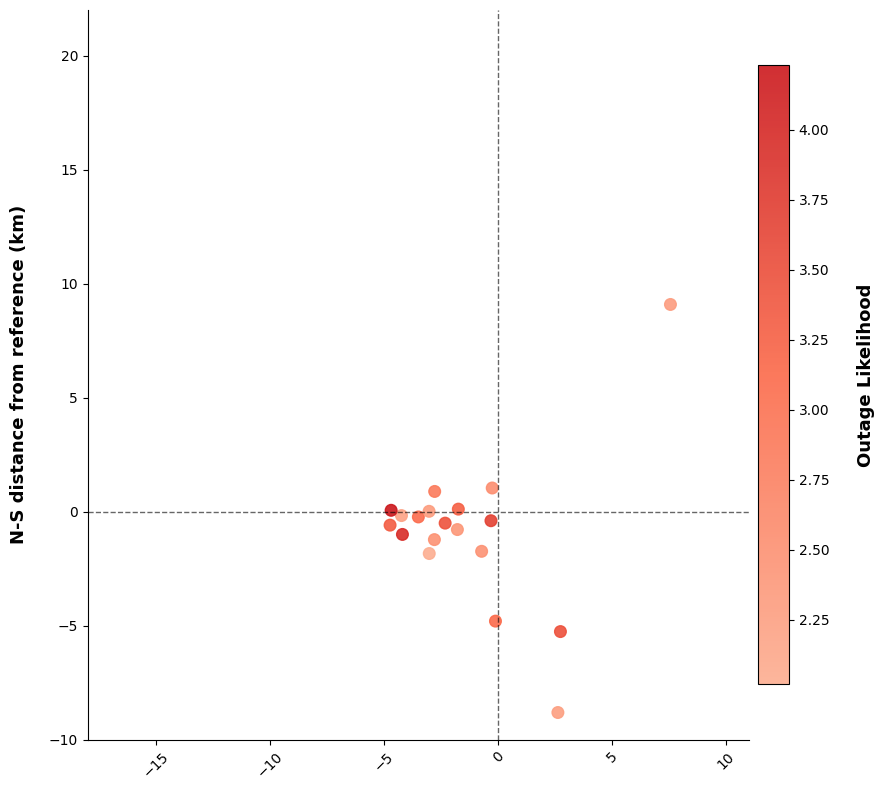

In [41]:
T = plot_centroid_distances_from_reference_binned(
    T_df,
    figsize = fig_size,
    base_gdf=district_gdf,
    use_base_df=True,
    use_km=True,
    use_bins=False,
    show_ylabel=True,
    show_xlabel=False,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset, 
    xlim=common_xlim,
    ylim=common_ylim, 
    colors=['#fcae91', '#fb6a4a', '#cb181d'], 
    # save_path=PLOTS_DIR / 'spatial/temperature_plot.png'

)

In [33]:
# PL = plot_centroid_distances_from_reference_binned(
#     PL_df,
#     figsize = fig_size,
#     base_gdf=district_gdf,
#     use_base_df=True,
#     use_km=True,
#     use_bins=False,
#     show_ylabel=True,
#     show_xlabel=True,
#     x_ref_offset=common_x_ref_offset,
#     y_ref_offset=common_y_ref_offset, 
#     xlim=common_xlim,
#     ylim=common_ylim, 
#     colors=['#fdd0a2', '#f16913', '#7f2704'],
#     # save_path=PLOTS_DIR / 'spatial/pl_plot.png'

# )

### Plotting all weather events as sub-panels 

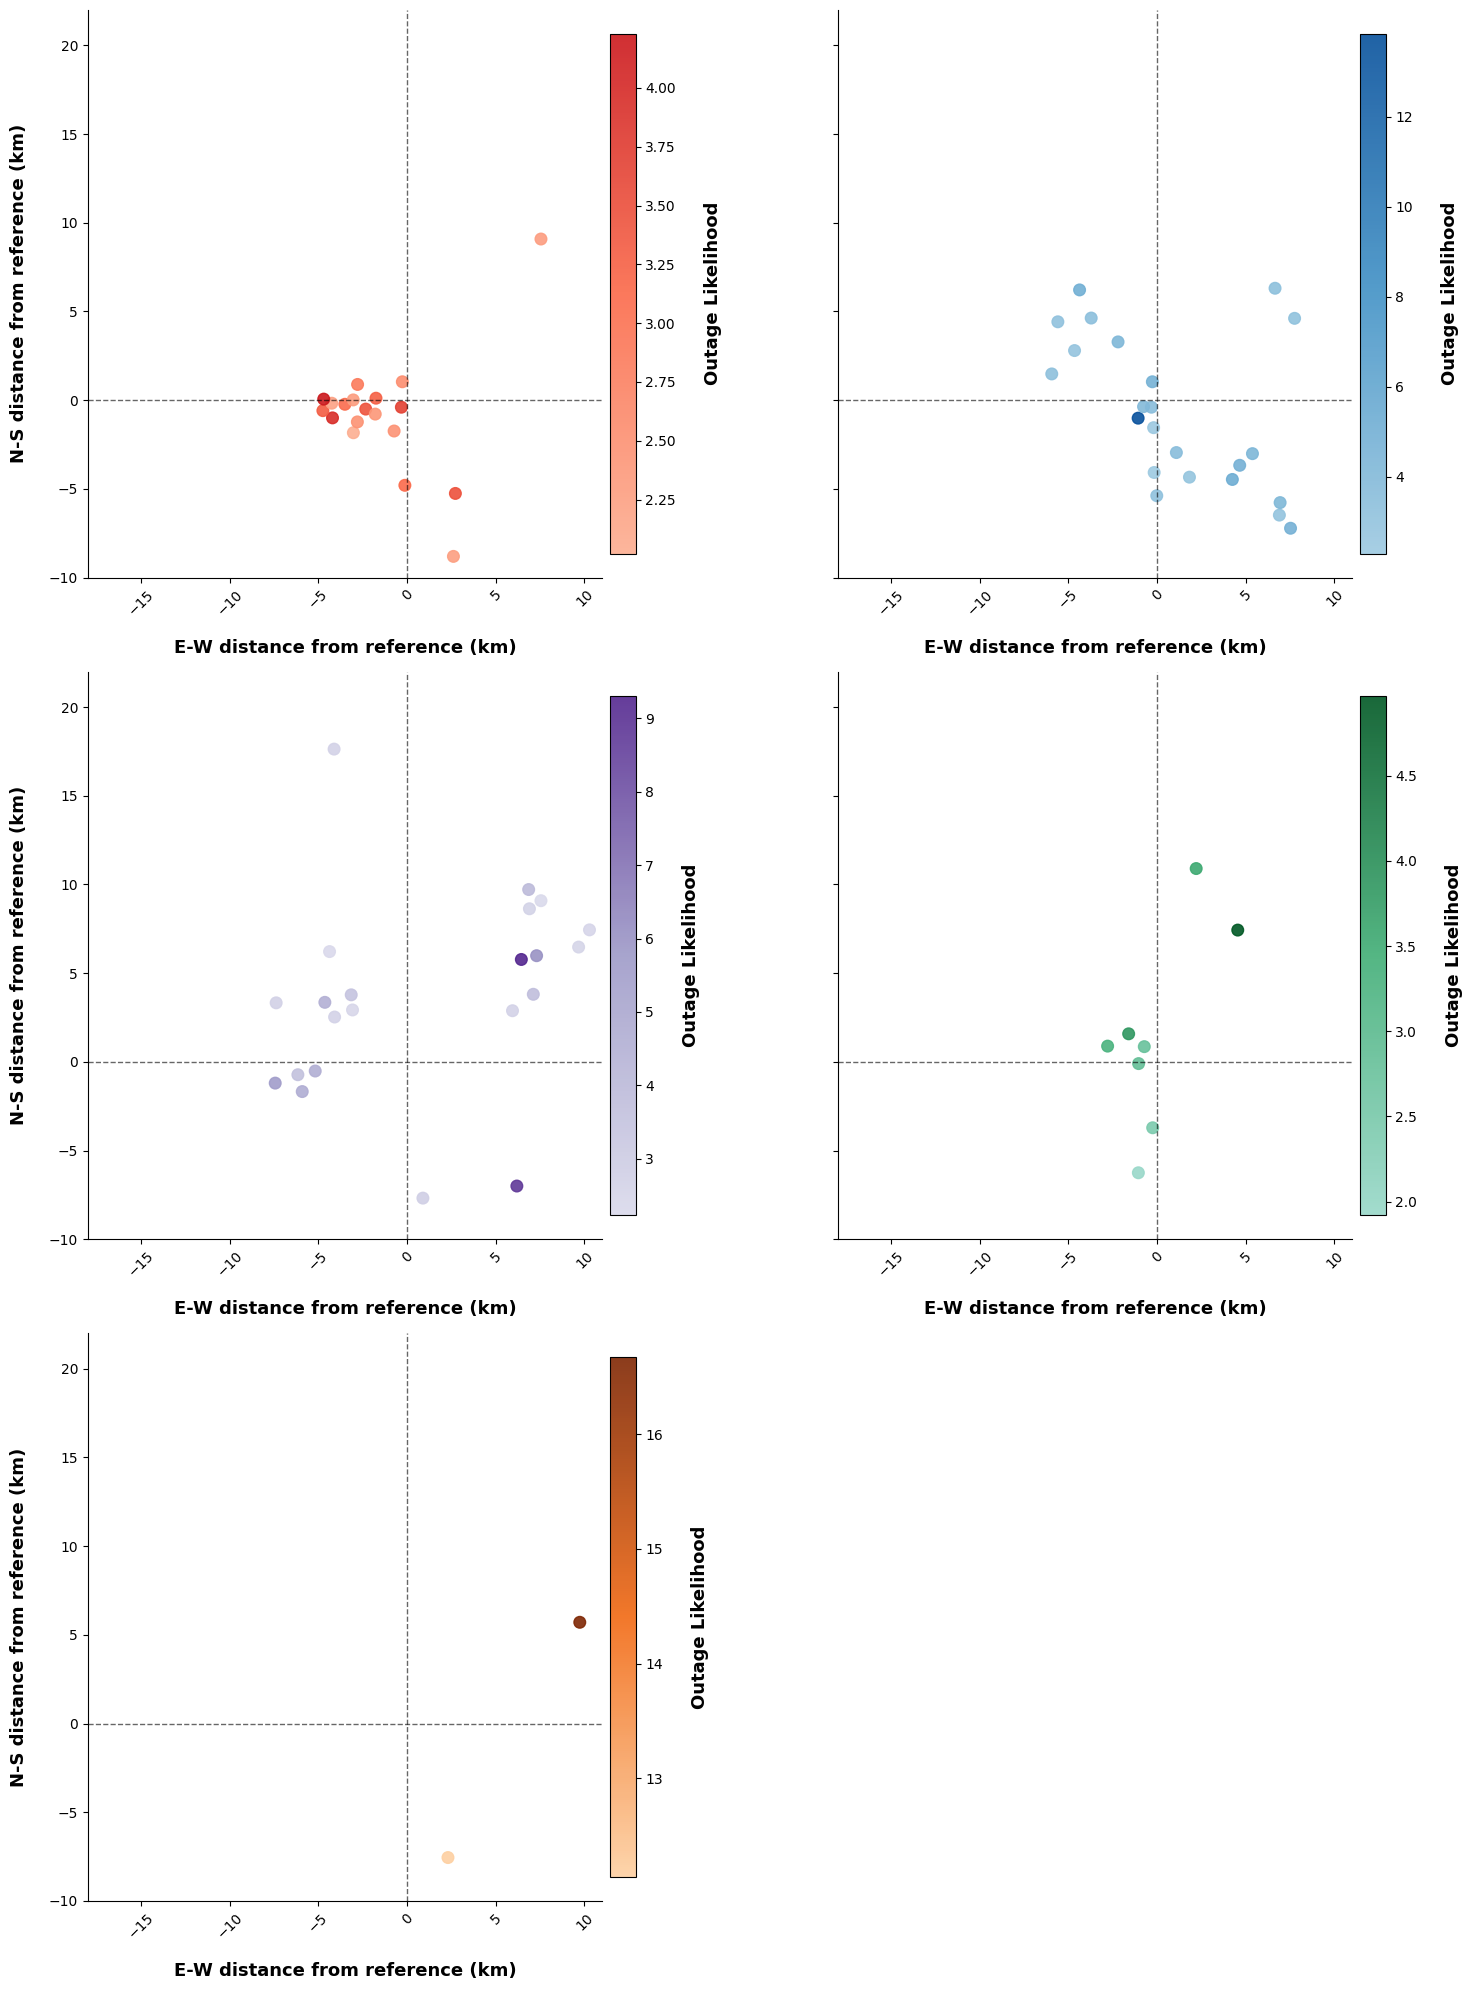

In [42]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 20),
    sharex=False,
    sharey=True
)

# =================================================
# ROW 1
# =================================================

# -------------------------
# Temperature
# -------------------------
T = plot_centroid_distances_from_reference_binned(
    T_df,
    ax=axes[0, 0],
    show=False,
    show_ylabel=True,
    cbar_label='Outage Likelihood',
    base_gdf=district_gdf,
    use_base_df=True,
    use_km=True,
    use_bins=False,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    colors=['#fcae91', '#fb6a4a', '#cb181d']
)

# -------------------------
# Precipitation
# -------------------------
P = plot_centroid_distances_from_reference_binned(
    P_df,
    ax=axes[0, 1],
    show=False,
    show_ylabel=False,
    cbar_label='Outage Likelihood',
    base_gdf=district_gdf,
    use_base_df=True,
    use_km=True,
    use_bins=False,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    colors=['#9ecae1', '#4292c6', '#08519c']
)

# =================================================
# ROW 2
# =================================================

# -------------------------
# Lightning
# -------------------------
L = plot_centroid_distances_from_reference_binned(
    L_df,
    ax=axes[1, 0],
    show=False,
    show_ylabel=True,
    cbar_label='Outage Likelihood',
    base_gdf=district_gdf,
    use_base_df=True,
    use_km=True,
    use_bins=False,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    colors=['#dadaeb', '#9e9ac8', '#54278f']
)

# -------------------------
# Wind
# -------------------------
W = plot_centroid_distances_from_reference_binned(
    W_df,
    ax=axes[1, 1],
    show=False,
    show_ylabel=False,
    cbar_label='Outage Likelihood',
    base_gdf=district_gdf,
    use_base_df=True,
    use_km=True,
    use_bins=False,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    colors=['#99d8c9', '#41ae76', '#005824']
)

# =================================================
# ROW 3
# =================================================

# -------------------------
# PL
# -------------------------
PL = plot_centroid_distances_from_reference_binned(
    PL_df,
    ax=axes[2, 0],
    show=False,
    show_ylabel=True,
    cbar_label='Outage Likelihood',
    base_gdf=district_gdf,
    use_base_df=True,
    use_km=True,
    use_bins=False,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    colors=['#fdd0a2', '#f16913', '#7f2704']
)

# -------------------------------------------------
# Empty final panel
# -------------------------------------------------
axes[2, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.01)
plt.show()